<a href="https://colab.research.google.com/github/wykyty/learning-journey/blob/main/01-sparse-autoencoders/05_training_sae_t5_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demo: Training a SAE on T5 Decoder

Quick demo to verify the pipeline works. Uses **t5-small** and minimal hyperparameters.

- Model: `t5-small` (d_model=512, 6 layers)
- SAE: d_sae=1024 (2x expansion)
- Training: 200 steps, batch_size=512
- Dataset: XSum (summarization, encoder-decoder pairs)

In [ ]:
try:
    import google.colab  # type: ignore
    %pip install transformer-lens torch datasets safetensors tqdm matplotlib
except Exception:
    from IPython import get_ipython  # type: ignore
    ipython = get_ipython()
    assert ipython is not None
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")

In [ ]:
import os, json, torch, torch.nn as nn, torch.nn.functional as F, numpy as np
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm
from safetensors.torch import save_file, load_file
from transformer_lens import HookedEncoderDecoder
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 1. Load T5-small

In [ ]:
model = HookedEncoderDecoder.from_pretrained("google-t5/t5-small")
model.eval()
tokenizer = model.tokenizer
print(f"d_model={model.cfg.d_model}, d_mlp={model.cfg.d_mlp}, n_layers={model.cfg.n_layers}")

## 2. Verify decoder activation capture

In [ ]:
enc_tokens = tokenizer("The quick brown fox.", return_tensors="pt")
dec_tokens = tokenizer("A fox.", return_tensors="pt")

logits, cache = model.run_with_cache(
    enc_tokens.input_ids, decoder_input=dec_tokens.input_ids,
)
hook_name = "decoder.3.hook_mlp_out"  # t5-small: 6 layers, target layer 3
print(f"{hook_name}: {cache[hook_name].shape}")  # [1, dec_seq, 512]

## 3. Config & SAE

In [ ]:
@dataclass
class SAEConfig:
    d_in: int = 512        # t5-small d_model
    d_sae: int = 1024      # 2x expansion (small for demo)
    lr: float = 1e-3
    batch_size: int = 512
    context_size: int = 64
    target_size: int = 32
    total_steps: int = 200
    l1_coefficient: float = 3.0
    l1_warm_up_steps: int = 10
    decoder_init_norm: float = 0.1
    apply_b_dec_to_input: bool = False
    normalize_activations: bool = True
    n_batches_for_norm_estimate: int = 5
    target_block: int = 3
    hook_name: str = "decoder.3.hook_mlp_out"
    log_every: int = 10
    device: str = device
    dtype: str = "float32"

config = SAEConfig()
print(f"d_in={config.d_in}, d_sae={config.d_sae}, total_steps={config.total_steps}")

In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, cfg: SAEConfig):
        super().__init__()
        self.cfg = cfg
        self.dtype = getattr(torch, cfg.dtype)
        self.W_dec = nn.Parameter(torch.empty(cfg.d_sae, cfg.d_in, dtype=self.dtype))
        self.W_enc = nn.Parameter(torch.empty(cfg.d_in, cfg.d_sae, dtype=self.dtype))
        self.b_enc = nn.Parameter(torch.zeros(cfg.d_sae, dtype=self.dtype))
        self.b_dec = nn.Parameter(torch.zeros(cfg.d_in, dtype=self.dtype))
        self.register_buffer("scaling_factor", torch.tensor(1.0))
        # Init: kaiming -> normalize rows to 0.1 -> W_enc = W_dec.T
        nn.init.kaiming_uniform_(self.W_dec.data)
        with torch.no_grad():
            self.W_dec.data /= self.W_dec.norm(dim=-1, keepdim=True)
            self.W_dec.data *= cfg.decoder_init_norm
        self.W_enc.data = self.W_dec.data.T.clone().detach().contiguous()

    def estimate_scaling_factor(self, data_loader, n_batches=5):
        norms = []
        for i, batch in enumerate(data_loader):
            if i >= n_batches: break
            norms.append(batch.float().norm(dim=-1).mean().item())
        self.scaling_factor = torch.tensor((self.cfg.d_in ** 0.5) / np.mean(norms), device=self.cfg.device)
        print(f"scaling_factor={self.scaling_factor.item():.4f} (mean_norm={np.mean(norms):.2f}, target={self.cfg.d_in**0.5:.2f})")

    def forward(self, x):
        x_scaled = x * self.scaling_factor if self.cfg.normalize_activations else x
        feature_acts = F.relu(x_scaled @ self.W_enc + self.b_enc)
        reconstruction = feature_acts @ self.W_dec + self.b_dec
        return reconstruction, feature_acts

    def calculate_loss(self, x, reconstruction, feature_acts, l1_coeff):
        per_item_mse = F.mse_loss(reconstruction, x, reduction="none")
        mse_loss = per_item_mse.sum(dim=-1).mean()
        weighted_acts = feature_acts * self.W_dec.norm(dim=1)
        l1_loss = l1_coeff * weighted_acts.norm(p=1, dim=-1).mean()
        with torch.no_grad():
            ev = 1 - per_item_mse.sum(-1).mean() / ((x - x.mean(0)).pow(2).sum(-1).mean() + 1e-8)
            l0 = feature_acts.bool().float().sum(-1).mean()
        return {"total": mse_loss + l1_loss, "mse": mse_loss, "l1": l1_loss, "ev": ev, "l0": l0}

    def save_model(self, path):
        path = Path(path); path.mkdir(parents=True, exist_ok=True)
        save_file({"W_enc": self.W_enc.data, "W_dec": self.W_dec.data,
                    "b_enc": self.b_enc.data, "b_dec": self.b_dec.data,
                    "scaling_factor": self.scaling_factor}, str(path / "sae_weights.safetensors"))
        print(f"Saved to {path}")

sae = SparseAutoencoder(config)
print(f"SAE params: {sum(p.numel() for p in sae.parameters()):,}")

## 4. Activation Collector

In [ ]:
class DecoderActivationCollector:
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.hook_name = config.hook_name
        self.tokenizer = model.tokenizer

    @torch.no_grad()
    def collect_activations(self, sources, targets):
        collected = []
        for src, tgt in zip(sources, targets):
            enc = self.tokenizer(src, return_tensors="pt", truncation=True, max_length=self.config.context_size)
            dec = self.tokenizer(tgt, return_tensors="pt", truncation=True, max_length=self.config.target_size)
            _, cache = self.model.run_with_cache(
                enc.input_ids, decoder_input=dec.input_ids,
                attention_mask=enc.attention_mask,
                names_filter=lambda n: n == self.hook_name,
            )
            acts = cache[self.hook_name].squeeze(0).float()[:dec.input_ids.shape[1]]
            collected.append(acts)
        return torch.cat(collected, dim=0) if collected else torch.empty(0, self.config.d_in)

    def collect_batch(self, dataset_iter, target_tokens=512):
        collected, total = [], 0
        while total < target_tokens:
            try:
                sample = next(dataset_iter)
            except StopIteration:
                break
            src, tgt = sample["document"], sample["summary"]
            if not src.strip() or not tgt.strip(): continue
            acts = self.collect_activations([src], [tgt])
            if acts.shape[0] > 0:
                collected.append(acts)
                total += acts.shape[0]
        if not collected: return torch.empty(0, self.config.d_in)
        all_acts = torch.cat(collected, dim=0)
        if all_acts.shape[0] > target_tokens:
            all_acts = all_acts[torch.randperm(all_acts.shape[0])[:target_tokens]]
        return all_acts

## 5. Train (200 steps)

In [ ]:
dataset = load_dataset("EdinburghNLP/xsum", split="train", streaming=True)
dataset_iter = iter(dataset)
collector = DecoderActivationCollector(model, config)

# Estimate scaling factor
sae.to(device)
sae.train()

def temp_provider():
    while True:
        acts = collector.collect_batch(dataset_iter, target_tokens=512)
        if acts.shape[0] > 0: yield acts

sae.estimate_scaling_factor(temp_provider(), n_batches=config.n_batches_for_norm_estimate)

# Training loop
optimizer = torch.optim.Adam(sae.parameters(), lr=config.lr, betas=(0.9, 0.999))
metrics = {"step": [], "total": [], "mse": [], "l1": [], "ev": [], "l0": []}

pbar = tqdm(range(config.total_steps), desc="Training")
for step in pbar:
    batch_acts = collector.collect_batch(dataset_iter, target_tokens=config.batch_size)
    if batch_acts.shape[0] == 0: continue

    reconstruction, feature_acts = sae(batch_acts)
    l1_coeff = config.l1_coefficient * min(1.0, step / config.l1_warm_up_steps)
    losses = sae.calculate_loss(batch_acts, reconstruction, feature_acts, l1_coeff)

    optimizer.zero_grad()
    losses["total"].backward()
    torch.nn.utils.clip_grad_norm_(sae.parameters(), 1.0)
    optimizer.step()

    for k in ["total", "mse", "l1", "ev", "l0"]:
        metrics[k].append(losses[k].item())
    metrics["step"].append(step)

    if step % config.log_every == 0:
        pbar.set_postfix({k: f"{losses[k].item():.3f}" for k in ["total", "ev", "l0"]})

print("\nTraining done!")

这里会报 WARNING:root:No attention mask provided. Assuming all tokens should be attended to.

1.是什么：

这个 warning 是 TransformerLens 的 HookedEncoderDecoder.run_with_cache 发出的。你传了 enc.input_ids 但没传
  attention_mask，TransformerLens 不知道哪些 token 该 attend，就默认全部 attend。

  在没有 padding 的情况下这完全正确（所有 token 确实都该被 attend），所以 warning 无害。但可以显式传 mask 消除它。

2.修复：

在 `run_with_cache` 调用中加了 `attention_mask=enc.attention_mask`，显式告诉 TransformerLens 哪些 token 该
  attend，warning 就不会再出现了。


训练结果：
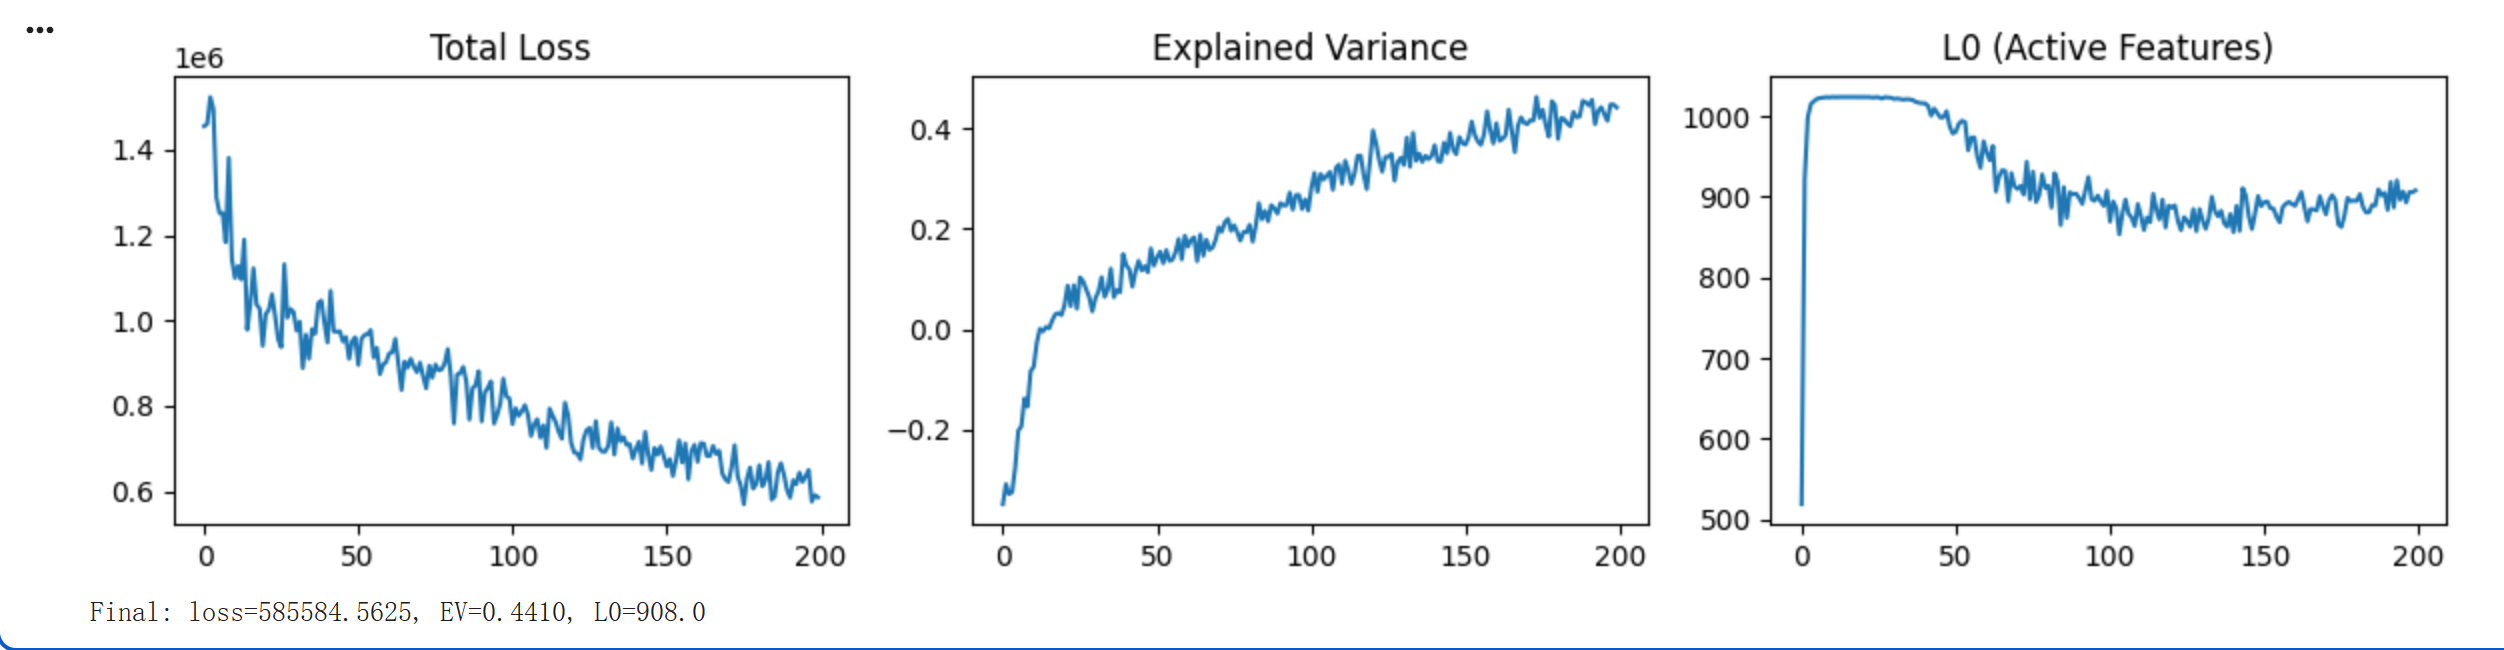

## 6. Quick check

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(metrics["step"], metrics["total"])
axes[0].set_title("Total Loss")
axes[1].plot(metrics["step"], metrics["ev"])
axes[1].set_title("Explained Variance")
axes[2].plot(metrics["step"], metrics["l0"])
axes[2].set_title("L0 (Active Features)")
plt.tight_layout()
plt.show()

print(f"Final: loss={metrics['total'][-1]:.4f}, EV={metrics['ev'][-1]:.4f}, L0={metrics['l0'][-1]:.1f}")

In [ ]:
# Logit lens: what tokens do features promote?
# @torch.no_grad()
# def logit_lens(sae, n=5):
#     proj = sae.W_dec @ model.W_E.T  # [d_sae, d_vocab]
#     vals, inds = proj.topk(5, dim=1)
#     for idx in torch.randint(0, proj.shape[0], (n,)):
#         f = idx.item()
#         tokens = [model.to_string(i) for i in inds[f]] # 报错：AttributeError: 'HookedEncoderDecoder' object has no attribute 'to_string'
#         print(f"Feature {f:4d}: {tokens}")

# logit_lens(sae)

# Logit lens: what tokens do features promote?
@torch.no_grad()
def logit_lens(sae, n=5):
    proj = sae.W_dec @ model.W_E.T  # [d_sae, d_vocab]
    vals, inds = proj.topk(5, dim=1)
    for idx in torch.randint(0, proj.shape[0], (n,)):
        f = idx.item()
        # 将 model.to_string(i) 替换为 tokenizer.decode
        tokens = [tokenizer.decode(i.item()) for i in inds[f]]
        print(f"Feature {f:4d}: {tokens}")

logit_lens(sae)

输出：

Feature  369: ['grès', 'inventor', 'ETH', 'lays', 'frères']

Feature  785: ['</s>', 'imunitar', 'suprafete', 'gradina', 'gasesc']

Feature  491: ['sixty', 'seventeen', '</s>', 'twenty', 'fifty']

Feature  127: ['lum', 'mas', 'rendez', 'assi', 'uba']

Feature  604: ['thinking', 'sunet', 'forcing', 'spending', 'switching']

## Done

Pipeline verified. For real training, scale up:
- `t5-large` (d_model=1024, 24 layers)
- `d_sae=16384` (16x expansion)
- `total_steps=50000`
- `batch_size=4096`